# Homework 2

This Notebook will detail Homework 2, which involves a basic capacity expansion model formulation described in [Notebook 3](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks)

First, load (or install if necessary) a set of packages you'll need for this assignment...

In [1]:
# Uncomment and run this first line if you need to install or update packages
# import Pkg; Pkg.add("JuMP"); Pkg.add("HiGHS"); Pkg.add("DataFrames"); Pkg.add("CSV")
using JuMP
using HiGHS
using DataFrames
using CSV

### Question 1 - Build the basic thermal generation expansion model

Using the example model in [Notebook 3](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks) as your guide, input the code to create a basic thermal generator capacity expansion model, including [downloading the data for Notebook 3 here](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks/expansion_data) and loading the appropriate csv files.

In [2]:
# load the data from Notebook 3
path = joinpath("..","Notebooks", "expansion_data")
generators = CSV.read(joinpath(path, "generators_for_expansion.csv"), DataFrame)
demand = CSV.read(joinpath(path, "demand_for_expansion.csv"), DataFrame)

Row,Hour,Demand
,Int64,Int64
1,1,2274
2,2,2581
3,3,2576
4,4,2482
5,5,2396
6,6,2193
7,7,1929
8,8,1715
9,9,1555


In [3]:
generators

Row,G,Description,Capex,FixedOM,VarOM,HeatRate,FuelCost,WACC,AssetLife,CRF,Annuity,FixedCost,VarCost
,String7,String31,Int64,Int64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Int64,Float64
1,Geo,Geothermal,7500000,130000,0,28.4,0,0.04,30,0.0578,433500,563500,0.0
2,Coal,Supercritical Coal,2600000,120000,8,8.1,2,0.04,30,0.0578,150280,270280,24.2
3,CCGT,Natural gas CCGT,1000000,28000,2,6.4,4,0.035,30,0.0544,54400,82400,27.6
4,CT,Natural gas CT,770000,21000,5,9.7,4,0.035,30,0.0544,41888,62888,43.8
5,Wind,Onshore wind,1000000,40000,0,1.0,0,0.03,30,0.051,51000,91000,0.0
6,Solar,Tracking solar PV,750000,15000,0,1.0,0,0.025,30,0.0478,35850,50850,0.0


In [4]:

NSECost = 9000 # $/MW-year
G = generators.G[1:(size(generators,1)-2)]  # indexing through generators not including wind and solar for now (thermal only)
H = demand.Hour; # indexing through hours

# create the model
Expansion_Model = Model(HiGHS.Optimizer)
# define the decision variables
@variables(Expansion_Model, begin
        CAP[g in G] >=0          # Generating capacity built (MW)
        GEN[g in G, h in H] >= 0 # Generation in each hour (MWh)
        NSE[h in H] >= 0         # Non-served energy in each hour (MWh)
end)
# define the constraints
@constraints(Expansion_Model, begin
    cDemandBalance[h in H], sum(GEN[g,h] for g in G) + NSE[h] == demand.Demand[h]
    cCapacity[g in G, h in H], GEN[g,h] <= CAP[g]
end)
# define the objective function
@objective(Expansion_Model, Min,
    sum(generators[generators.G.==g,:FixedCost][1]*CAP[g] + 
        sum(generators[generators.G.==g,:VarCost][1]*GEN[g,h] for h in H)
    for g in G) + 
    sum(NSECost*NSE[h] for h in H) 
);

Expansion_Model # look at the model


A JuMP Model
├ solver: HiGHS
├ objective_sense: MIN_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 43804
├ num_constraints: 87604
│ ├ AffExpr in MOI.EqualTo{Float64}: 8760
│ ├ AffExpr in MOI.LessThan{Float64}: 35040
│ └ VariableRef in MOI.GreaterThan{Float64}: 43804
└ Names registered in the model
  └ :CAP, :GEN, :NSE, :cCapacity, :cDemandBalance

In [5]:
optimize!(Expansion_Model) # Solve the model

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
LP has 43800 rows; 43804 cols; 113880 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [2e+01, 6e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 5e+03]
Presolving model
43800 rows, 43804 cols, 113880 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
43800 rows, 43804 cols, 113880 nonzeros  0s
Presolve reductions: rows 43800(-0); columns 43804(-0); nonzeros 113880(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(2.25679e+07) 0.1s
      27493     9.9087397880e+08 Pr: 0(0) 0.4s

Model status        : Optimal
Simplex   iterations: 27493
Objective value     :  9.9087397880e+08
P-D objectiv

In [6]:

generation = zeros(size(G,1))
for i in 1:size(G,1) 
    generation[i] = sum(value.(GEN)[G[i],:].data) 
end
MWh_share = generation./sum(demand.Demand).*100
cap_share = value.(CAP).data./maximum(demand.Demand).*100
results = DataFrame(
    Resource = G, 
    MW = value.(CAP).data,
    Percent_MW = cap_share,
    GWh = generation/1000,
    Percent_GWh = MWh_share
)
# Calculate how much non-served energy there was and add to results
  # The maximum MW of non-served energy is the difference 
  # between peak demand and total installed generation capacity
NSE_MW = maximum(value.(NSE).data) 
  # The total MWh of non-served energy is the difference between
  # total demand and total generation
NSE_MWh = sum(value.(NSE).data)
  # Add or "push" a new row of data to the end of the results DataFrame
push!(results, ["NSE" NSE_MW NSE_MW/maximum(demand.Demand)*100 NSE_MWh/1000 NSE_MWh/sum(demand.Demand)*100])

Row,Resource,MW,Percent_MW,GWh,Percent_GWh
,String7,Float64,Float64,Float64,Float64
1,Geo,0.0,0.0,-0.0,-0.0
2,Coal,0.0,0.0,-0.0,-0.0
3,CCGT,3328.0,69.1461,22139.4,98.1011
4,CT,1290.0,26.8024,427.894,1.89603
5,NSE,195.0,4.05153,0.637,0.00282259


## Question 2: Analytical solution

**A.** Using the data provided above, sort the demand data from highest to lowest hours to create a load duration curve and save this as a vector/array/DataFrame of your choice.

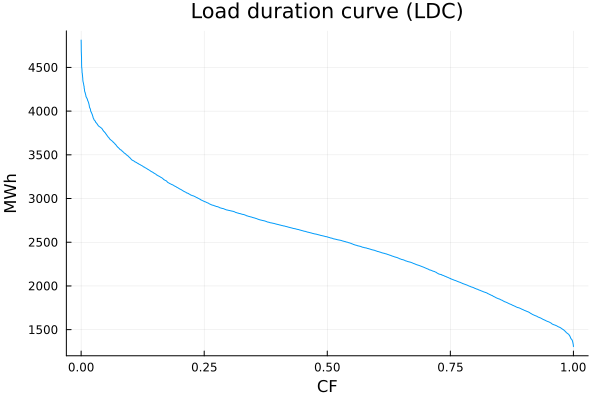

In [7]:
using Plots

plot(range(0,1,length=8760), sort(demand.Demand, rev=true), label="")
title!("Load duration curve (LDC)")
xaxis!("CF")
yaxis!("MWh")

**B.** Now using the cost data provided in '/generators_for_expansion.csv' and the load duration curve above, use the formulas provided in Lecture to determine an analytical solution to the optimal thermal generation expansion decisions (e.g. solve it algebraically rather than use an optimization solver to find the solution). 

Report the optimal capacity of each generation source and compare to the solution from the optimization model above. 

Show your work in cells below, using Julia to perform calculations. Explain your steps using inline code comments (e.g. `# Comment`) or by interspersing Markdown cells.  

Tip: round your solutions for the crossover hour between each technology to the nearest integer (as we have discrete hours in the time series).

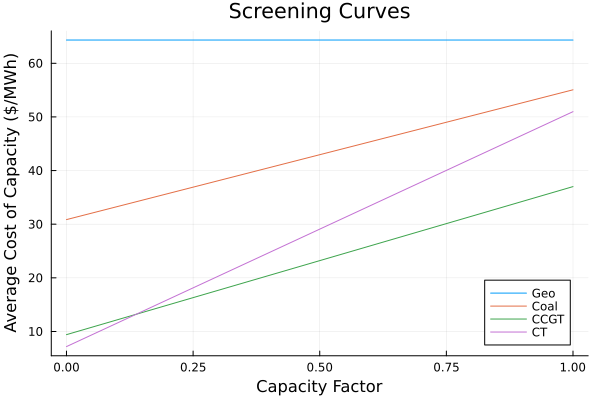

In [ ]:
# solve analytically using screening curve

# calculate the screening curve for each generator
cf = range(0,1,length=8760)
plot()  # Initialize an empty plot

for g in G
    fixed_cost = generators[generators.G.==g,:FixedCost][1] # rescale fixed cost
    fixed_cost_normalized = (fixed_cost) ./ 8760  # rescale fixed cost to $/MWh
    var_cost = generators[generators.G.==g,:VarCost][1] # already in $/MWh
    screening_curve = var_cost .* cf .+ fixed_cost_normalized # $/MWh
    plot!(cf, screening_curve, label=string(g))
end

title!("Screening Curves")
xaxis!("Capacity Factor")
yaxis!("Average Cost of Capacity (\$/MWh)")


In [44]:
# now I know that the CT and CCGT are the most price efficient

# collect the values of the screening curve over the range of CF for CT
fixed_cost_CCGT = generators[generators.G.=="CCGT",:FixedCost][1]
var_cost_CCGT = generators[generators.G.=="CCGT",:VarCost][1]
screening_CCGT = var_cost_CCGT .* cf .+ fixed_cost_CCGT ./ 8760

# collect the values of the screening curve over the range of CF for CT
fixed_cost_CT = generators[generators.G.=="CT",:FixedCost][1]
var_cost_CT = generators[generators.G.=="CT",:VarCost][1]
screening_CT = var_cost_CT .* cf .+ fixed_cost_CT ./ 8760

# find the first index and CF where CT > CCGT
for i in 1:length(cf)
    if screening_CT[i] > screening_CCGT[i]
        println("Index: $i, CF: $(cf[i])")
        return idx = i
        break
    end
end

Index: 665, CF: 0.07580774060965864


665

In [35]:
load_duration_curve= sort(demand.Demand, rev=true)
installed_MWh_CCGT = load_duration_curve[idx] # this is the load at the intersection of the screening curves
installed_MWh_CT = maximum(demand.Demand) - installed_MWh_CCGT
println("Installed MWh of CCGT: $installed_MWh_CCGT")
println("Installed MWh of CT: $installed_MWh_CT")

Installed MWh of CCGT: 3581
Installed MWh of CT: 1232


**C.** Now change the fuel cost of natural gas to \$8.00/MMBtu, recalculate the variable cost of CCGTs and CTs, and solve again for the optimal generation capacity mix. Describe what changes in your capacity results and what doesn't, and provide an explanation.

In [19]:
# create a copy of the generators DataFrame to modify for the new fuel costs 
new_generators = generators

# update the fuel costs for CCGT and CT to $8/MWh
new_generators[new_generators.G.=="CCGT",:FuelCost] .= 8.0
new_generators[new_generators.G.=="CT",:FuelCost] .= 8.0

#update the variable costs for CCGT and CT based on the new fuel costs HeatRate*FuelCost + VarOM
new_generators[new_generators.G.=="CCGT",:VarCost] .= new_generators[new_generators.G.=="CCGT",:HeatRate][1]*new_generators[new_generators.G.=="CCGT",:FuelCost][1]+new_generators[new_generators.G.=="CCGT",:VarOM][1]
new_generators[new_generators.G.=="CT",:VarCost] .= new_generators[new_generators.G.=="CT",:HeatRate][1]*new_generators[new_generators.G.=="CT",:FuelCost][1]+new_generators[new_generators.G.=="CT",:VarOM][1]

#check the updated variable costs
new_generators

Row,G,Description,Capex,FixedOM,VarOM,HeatRate,FuelCost,WACC,AssetLife,CRF,Annuity,FixedCost,VarCost
,String7,String31,Int64,Int64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Int64,Float64
1,Geo,Geothermal,7500000,130000,0,28.4,0,0.04,30,0.0578,433500,563500,0.0
2,Coal,Supercritical Coal,2600000,120000,8,8.1,2,0.04,30,0.0578,150280,270280,24.2
3,CCGT,Natural gas CCGT,1000000,28000,2,6.4,8,0.035,30,0.0544,54400,82400,53.2
4,CT,Natural gas CT,770000,21000,5,9.7,8,0.035,30,0.0544,41888,62888,82.6
5,Wind,Onshore wind,1000000,40000,0,1.0,0,0.03,30,0.051,51000,91000,0.0
6,Solar,Tracking solar PV,750000,15000,0,1.0,0,0.025,30,0.0478,35850,50850,0.0


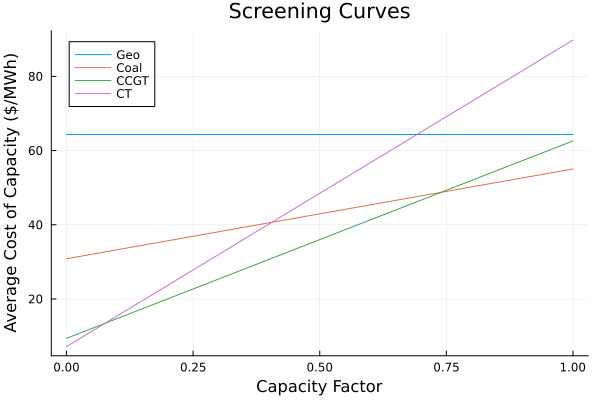

In [36]:
# do the same screening curve analysis with the new variable costs to find the new intersection point and new installed capacity of CCGT and CT
cf = range(0,1,length=8760)
plot()  # Initialize an empty plot

for g in G
    fixed_cost = new_generators[new_generators.G.==g,:FixedCost][1] # rescale fixed cost
    fixed_cost_normalized = (fixed_cost) ./ 8760  # rescale fixed cost to $/MWh
    var_cost = new_generators[new_generators.G.==g,:VarCost][1] # already in $/MWh
    screening_curve = var_cost .* cf .+ fixed_cost_normalized # $/MWh
    plot!(cf, screening_curve, label=string(g))
end

title!("Screening Curves")
xaxis!("Capacity Factor")
yaxis!("Average Cost of Capacity (\$/MWh)")

In [77]:
# do the analysis to find the new intersection point of the screening curves for CCGT and CT
# collect the values of the screening curve over the range of CCGT for CT
fixed_cost_CCGT = new_generators[new_generators.G.=="CCGT",:FixedCost][1]
new_var_cost_CCGT = new_generators[new_generators.G.=="CCGT",:VarCost][1]
new_screening_CCGT = new_var_cost_CCGT .* cf .+ fixed_cost_CCGT ./ 8760

# collect the values of the screening curve over the range of CF for CT
fixed_cost_CT = new_generators[new_generators.G.=="CT",:FixedCost][1]
new_var_cost_CT = new_generators[new_generators.G.=="CT",:VarCost][1]
new_screening_CT = new_var_cost_CT .* cf .+ fixed_cost_CT ./ 8760

# find the first index and CF where CT > CCGT
cf_idx = 0
for i in 1:length(cf)
    if new_screening_CT[i] > new_screening_CCGT[i]
        cf_idx = i
        println("Index: $i, CF: $(cf[i])")
        break
    end
end

# find the first index and CF where CCGT > coal
fixed_cost_coal = new_generators[new_generators.G.=="Coal",:FixedCost][1]
new_var_cost_coal = new_generators[new_generators.G.=="Coal",:VarCost][1]
new_screening_coal = new_var_cost_coal .* cf .+ fixed_cost_coal ./ 8760 

cf2_idx = 0
for i in 1:length(cf)
    if new_screening_CCGT[i] > new_screening_coal[i]
        cf2_idx = i
        println("Index: $i, CF: $(cf[i])")
        break
    end
end


load_duration_curve = sort(demand.Demand, rev=true)
new_installed_MWh_coal = load_duration_curve[cf2_idx] # this is the load at the intersection of the screening curves
new_installed_MWh_CCGT = load_duration_curve[cf_idx] - new_installed_MWh_coal# this is the load at the intersection of the screening curves
new_installed_MWh_CT = maximum(load_duration_curve) - load_duration_curve[cf_idx]  # this is the load at the intersection of the screening curves
println("Installed MWh of Coal: $new_installed_MWh_coal")
println("Installed MWh of CCGT: $new_installed_MWh_CCGT")
println("Installed MWh of CT: $new_installed_MWh_CT")

Index: 665, CF: 0.07580774060965864
Index: 6479, CF: 0.7395821440803745
Installed MWh of Coal: 2110
Installed MWh of CCGT: 1471
Installed MWh of CT: 1232


In [42]:
# check with optimize solver
NSECost = 9000 # $/MW-year
G = new_generators.G[1:(size(new_generators,1)-2)]  # indexing through generators not including wind and solar for now (thermal only)
H = demand.Hour; # indexing through hours

# create the model
new_Expansion_Model = Model(HiGHS.Optimizer)

# define the decision variables
@variables(new_Expansion_Model, begin
        new_CAP[g in G] >=0          # Generating capacity built (MW)
        new_GEN[g in G, h in H] >= 0 # Generation in each hour (MWh)
        new_NSE[h in H] >= 0         # Non-served energy in each hour (MWh)
end)

# define the constraints
@constraints(new_Expansion_Model, begin
    new_cDemandBalance[h in H], sum(new_GEN[g,h] for g in G) + new_NSE[h] == demand.Demand[h]
    new_cCapacity[g in G, h in H], new_GEN[g,h] <= new_CAP[g]
end)

# define the objective function
@objective(new_Expansion_Model, Min,
    sum(new_generators[new_generators.G.==g,:FixedCost][1]*new_CAP[g] + 
        sum(new_generators[new_generators.G.==g,:VarCost][1]*new_GEN[g,h] for h in H)
    for g in G) + 
    sum(NSECost*new_NSE[h] for h in H) 
);

new_Expansion_Model # look at the model

optimize!(new_Expansion_Model) # Solve the model

new_generation = zeros(size(G,1))
for i in 1:size(G,1) 
    new_generation[i] = sum(value.(new_GEN)[G[i],:].data) 
end
MWh_share = new_generation./sum(demand.Demand).*100
cap_share = value.(new_CAP).data./maximum(demand.Demand).*100
results = DataFrame(
    Resource = G, 
    MW = value.(new_CAP).data,
    Percent_MW = cap_share,
    GWh = new_generation/1000,
    Percent_GWh = MWh_share
)
# Calculate how much non-served energy there was and add to results
  # The maximum MW of non-served energy is the difference 
  # between peak demand and total installed generation capacity
NSE_MW = maximum(value.(new_NSE).data) 
  # The total MWh of non-served energy is the difference between
  # total demand and total generation
NSE_MWh = sum(value.(new_NSE).data)
  # Add or "push" a new row of data to the end of the results DataFrame
push!(results, ["NSE" NSE_MW NSE_MW/maximum(demand.Demand)*100 NSE_MWh/1000 NSE_MWh/sum(demand.Demand)*100])

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
LP has 43800 rows; 43804 cols; 113880 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [2e+01, 6e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 5e+03]
Presolving model
43800 rows, 43804 cols, 113880 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
43800 rows, 43804 cols, 113880 nonzeros  0s
Presolve reductions: rows 43800(-0); columns 43804(-0); nonzeros 113880(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(2.25679e+07) 0.1s
      24671     1.4540758470e+09 Pr: 0(0) 0.4s

Model status        : Optimal
Simplex   iterations: 24671
Objective value     :  1.4540758470e+09
P-D objectiv

Row,Resource,MW,Percent_MW,GWh,Percent_GWh
,String7,Float64,Float64,Float64,Float64
1,Geo,0.0,0.0,-0.0,-0.0
2,Coal,2110.0,43.8396,17751.1,78.6565
3,CCGT,1472.0,30.5838,4618.47,20.4648
4,CT,1036.0,21.525,197.67,0.87589
5,NSE,195.0,4.05153,0.637,0.00282259


Part C:
Increasing the price of gas changed the composition of the electricity generation by 

## Question 3 - Expansion with renewables

**A.** Using JuMP/Julia, implement an optimization model based on the formulation for optimal thermal+renewable capacity expansion provided in Section 2 of [Notebook 3](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks). 

In [ ]:

# create the model
RE_Expansion_Model = Model(HiGHS.Optimizer)



# define the decision variables
@variables(RE_Expansion_Model, begin
        new_CAP[g in G] >=0          # Generating capacity built (MW)
        new_GEN[g in G, h in H] >= 0 # Generation in each hour (MWh)
        new_NSE[h in H] >= 0         # Non-served energy in each hour (MWh)
end)

# define the constraints
@constraints(RE_Expansion_Model, begin
    new_cDemandBalance[h in H], sum(new_GEN[g,h] for g in G) + new_NSE[h] == demand.Demand[h]
    new_cCapacity[g in G, h in H], new_GEN[g,h] <= new_CAP[g]
end)

# define the objective function
@objective(RE_Expansion_Model, Min,
    sum(new_generators[new_generators.G.==g,:FixedCost][1]*new_CAP[g] + 
        sum(new_generators[new_generators.G.==g,:VarCost][1]*new_GEN[g,h] for h in H)
    for g in G) + 
    sum(NSECost*new_NSE[h] for h in H) 
);

RE_Expansion_Model # look at the model

optimize!(RE_Expansion_Model) # Solve the model


**B.** Solve the model to determine the optimal capacity when wind and solar are available resources and extract results for generation and capacity.

**C.** What happens to the total firm generation and maximum MW of non-served energy? What does this imply about the capacity value of solar and/or wind built in the optimal capacity mix?

## Question 4: Brownfield Expansion Model

**A.** Now implement an optimization model based on the formulation for optimal "brownfield" thermal+renewable capacity expansion (e.g. with existing generators) provided in Section 3 of [Notebook 3](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks).

Use the following data for fixed and variable costs of existing gas capacity. Note: unlike in the formulation in Notebook 3, there is no existing renewable capacity here to consider (only thermal).

In [ ]:
# Load new generator options
#path = joinpath([REPLACE THIS WITH PATH TO YOUR power-systems-optimization DIRECTORY HERE],"Notebooks","expansion_data")
path = joinpath("/Users/jdj2/Documents/GitHub/power-systems-optimization","Notebooks","expansion_data")
generators = DataFrame(CSV.File(joinpath(path,"generators_for_expansion.csv")))
# Add parameters for existing CCGTs, with the set index "Old"
push!(generators, ["Old_CC" "Existing CCGT" 0 40000 5 7.5 4 0 0 0 0 40000 30])
# Add parameters for existing CTs, with the set index "Old"
push!(generators, ["Old_CT" "Existing CT" 0 30000 11 11.0 4 0 0 0 0 30000 55])

# Set installed capacity for existing CCGTs:
ExistingCap_CCGT = 1260 # Approximate actual existing capacity in SDGE
ExistingCap_CT = 925 # Approximate actual existing capacity in SDGE
# Add new column to generators Data Frame
generators[!,:ExistingCap] = [0,0,0,0,0,0, ExistingCap_CCGT, ExistingCap_CT];

**B.** Solve the model to determine the optimal capacity when with existing generators and extract results for generation and capacity (including retirements).